In [ ]:
# ===============================
# 🦴 Bone TB Detection using CNN
# Google Colab Hackathon Starter
# ===============================

!pip install tensorflow opencv-python matplotlib

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import zipfile, os

In [ ]:
from google.colab import files
files.upload()  # upload the kaggle.json file you just downloaded

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bhoomichaudhary","key":"dc3be1334152fac9dd77351a0b6326d2"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d tawsifurrahman/tuberculosis-tb-chest-xray-dataset -p /content/data

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/tuberculosis-tb-chest-xray-dataset
License(s): copyright-authors
 93% 620M/663M [00:03<00:00, 65.6MB/s]
100% 663M/663M [00:03<00:00, 192MB/s] 


In [ ]:
!unzip -q /content/data/tuberculosis-tb-chest-xray-dataset.zip -d /content/data/tb_cleaned

In [ ]:
!ls /content/data/tb_cleaned

TB_Chest_Radiography_Database


In [ ]:
train_dir = "/content/data/tb_cleaned/TB_Chest_Radiography_Database/"
val_dir = "/content/data/tb_cleaned/TB_Chest_Radiography_Database/"

print("Training directory:", train_dir)
print("Validation directory:", val_dir)

Training directory: /content/data/tb_cleaned/TB_Chest_Radiography_Database/
Validation directory: /content/data/tb_cleaned/TB_Chest_Radiography_Database/


In [ ]:
!ls /content/data/tb_cleaned/TB_Chest_Radiography_Database/Normal | head
!ls /content/data/tb_cleaned/TB_Chest_Radiography_Database/Tuberculosis | head

Normal-1000.png
Normal-1001.png
Normal-1002.png
Normal-1003.png
Normal-1004.png
Normal-1005.png
Normal-1006.png
Normal-1007.png
Normal-1008.png
Normal-1009.png
Tuberculosis-100.png
Tuberculosis-101.png
Tuberculosis-102.png
Tuberculosis-103.png
Tuberculosis-104.png
Tuberculosis-105.png
Tuberculosis-106.png
Tuberculosis-107.png
Tuberculosis-108.png
Tuberculosis-109.png


In [ ]:
# Data augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)


Found 4200 images belonging to 2 classes.
Found 4200 images belonging to 2 classes.


In [ ]:
!ls -R /content/data/tb_cleaned/TB_Chest_Radiography_Database/

/content/data/tb_cleaned/TB_Chest_Radiography_Database/:
Normal		      README.md.txt  Tuberculosis.metadata.xlsx
Normal.metadata.xlsx  Tuberculosis

/content/data/tb_cleaned/TB_Chest_Radiography_Database/Normal:
Normal-1000.png  Normal-178.png   Normal-2577.png  Normal-3364.png
Normal-1001.png  Normal-1790.png  Normal-2578.png  Normal-3365.png
Normal-1002.png  Normal-1791.png  Normal-2579.png  Normal-3366.png
Normal-1003.png  Normal-1792.png  Normal-257.png   Normal-3367.png
Normal-1004.png  Normal-1793.png  Normal-2580.png  Normal-3368.png
Normal-1005.png  Normal-1794.png  Normal-2581.png  Normal-3369.png
Normal-1006.png  Normal-1795.png  Normal-2582.png  Normal-336.png
Normal-1007.png  Normal-1796.png  Normal-2583.png  Normal-3370.png
Normal-1008.png  Normal-1797.png  Normal-2584.png  Normal-3371.png
Normal-1009.png  Normal-1798.png  Normal-2585.png  Normal-3372.png
Normal-100.png	 Normal-1799.png  Normal-2586.png  Normal-3373.png
Normal-1010.png  Normal-179.png   Normal-2587.png  No

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras import optimizers

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 743s 6s/step - accuracy: 0.8431 - loss: 0.4193 - val_accuracy: 0.8855 - val_loss: 0.3804
Epoch 2/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 704s 5s/step - accuracy: 0.9093 - loss: 0.2447 - val_accuracy: 0.9188 - val_loss: 0.1601
Epoch 3/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 698s 5s/step - accuracy: 0.9252 - loss: 0.1859 - val_accuracy: 0.9305 - val_loss: 0.1478
Epoch 4/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 748s 5s/step - accuracy: 0.9426 - loss: 0.1505 - val_accuracy: 0.9295 - val_loss: 0.1519
Epoch 5/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 704s 5s/step - accuracy: 0.9394 - loss: 0.1455 - val_accuracy: 0.9531 - val_loss: 0.1104
Epoch 6/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 739s 6s/step - accuracy: 0.9517 - loss: 0.1226 - val_accuracy: 0.9417 - val_loss: 0.1280
Epoch 7/15
132/132 ━━━━━━━━━━━━━━━━━━━━ 694s 5s/step - accuracy: 0.9484 - loss: 0.1349 - val_accuracy: 0.9569 - val_loss: 0.1030
Epoch 8/15
 90/132 ━━━━━━━━━━━━━━━━━━━━ 2:50 4s/step - accuracy: 0.9594 - loss: 0.1246

In [ ]:
loss, acc = model.evaluate(val_data)
print(f"\n✅ Validation Accuracy: {acc*100:.2f}%")


132/132 ━━━━━━━━━━━━━━━━━━━━ 36s 269ms/step - accuracy: 0.9595 - loss: 0.0929

✅ Validation Accuracy: 95.69%


In [ ]:
model.save("bone_tb_cnn_model.h5")
print("💾 Model saved as bone_tb_cnn_model.h5")


💾 Model saved as bone_tb_cnn_model.h5


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)[0][0]
    label = "TB Positive" if prediction > 0.5 else "TB Negative"
    print(f"🩻 Prediction: {label} (Confidence: {prediction:.2f})")
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')
    plt.show()


📤 Upload an image to test prediction:


Saving TB 2.jpeg to TB 2.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
🩻 Prediction: TB Negative (Confidence: 0.29)


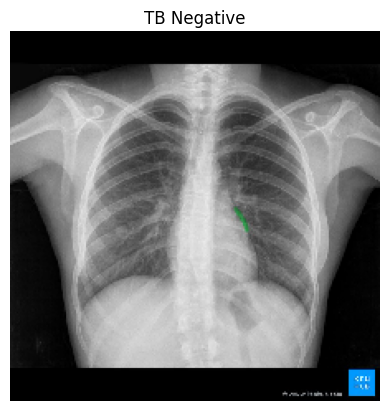

In [ ]:
from google.colab import files

print("📤 Upload an image to test prediction:")
uploaded_img = files.upload()

for img_name in uploaded_img.keys():
    predict_image(img_name)

In [ ]:
# ===========================
# 🚀 Transfer Learning: ResNet50
# ===========================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Load pre-trained ResNet50 model (exclude top layers)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)  # Binary classification

# Final model
resnet_model = Model(inputs=base_model.input, outputs=predictions)
resnet_model.summary()

# Compile model
resnet_model.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

📤 Upload an image to visualize Grad-CAM heatmap:


Saving TB 1.jpg to TB 1 (3).jpg


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_11']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


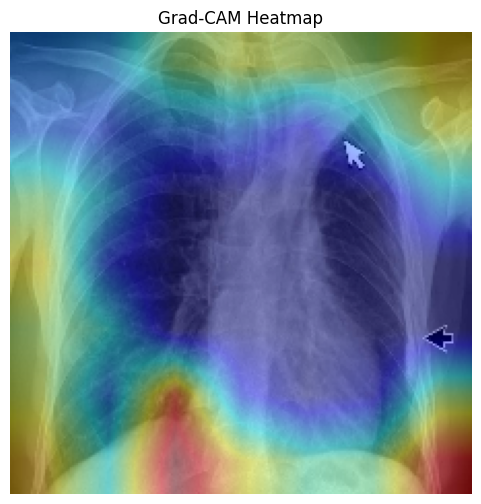

In [ ]:
# ===========================
# 🌈 Grad-CAM Visualization
# ===========================

import numpy as np
import matplotlib.cm as cm
from tensorflow.keras.preprocessing import image
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Get model gradient model (inputs → conv layer → predictions)
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute gradients of predicted class w.r.t. conv layer outputs
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    # Average gradients over all pixels
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    # Weight output feature maps by importance
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, model, last_conv_layer_name="conv5_block3_out"):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Make Grad-CAM heatmap
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # Display heatmap superimposed on original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(img, 0.6, heatmap_colored, 0.4, 0)

    # Convert BGR → RGB for plotting
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")
    plt.show()

# === Run Demo ===
print("📤 Upload an image to visualize Grad-CAM heatmap:")
uploaded_cam = files.upload()

for img_name in uploaded_cam.keys():
    display_gradcam(img_name, resnet_model, last_conv_layer_name="conv5_block3_out")  # use last conv layer name

In [ ]:
# ===========================
# 🚀 Transfer Learning: ResNet50
# ===========================

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

# Load pre-trained ResNet50 model (exclude top layers)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)  # Binary classification

# Final model
resnet_model = Model(inputs=base_model.input, outputs=predictions)
resnet_model.summary()

# Compile model
resnet_model.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='binary_crossentropy',
                     metrics=['accuracy'])


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train the ResNet50 model
history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,   # fewer epochs for demo
    verbose=1
)


Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 136s 940ms/step - accuracy: 0.6413 - loss: 0.6776 - val_accuracy: 0.8333 - val_loss: 0.4504
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 112s 850ms/step - accuracy: 0.8350 - loss: 0.4808 - val_accuracy: 0.8333 - val_loss: 0.4505
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 112s 847ms/step - accuracy: 0.8312 - loss: 0.4696 - val_accuracy: 0.8333 - val_loss: 0.4493
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 112s 853ms/step - accuracy: 0.8305 - loss: 0.4611 - val_accuracy: 0.8333 - val_loss: 0.4483
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 117s 885ms/step - accuracy: 0.8403 - loss: 0.4505 - val_accuracy: 0.8333 - val_loss: 0.4477
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 113s 855ms/step - accuracy: 0.8310 - loss: 0.4624 - val_accuracy: 0.8333 - val_loss: 0.4473
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 112s 849ms/step - accuracy: 0.8280 - loss: 0.4621 - val_accuracy: 0.8333 - val_loss: 0.4462
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 112s 848ms/step - accuracy: 0.8391 -

In [ ]:
loss, acc = resnet_model.evaluate(val_data)
print(f"\n✅ Validation Accuracy (ResNet50): {acc*100:.2f}%")


132/132 ━━━━━━━━━━━━━━━━━━━━ 37s 281ms/step - accuracy: 0.8345 - loss: 0.4437

✅ Validation Accuracy (ResNet50): 83.33%


In [ ]:
resnet_model.save("bone_tb_resnet50_model.h5")
print("💾 ResNet50 model saved as bone_tb_resnet50_model.h5")
